# Task 3 — A/B Hypothesis Testing

**Objective:** Statistically validate or reject key hypotheses about risk drivers, forming the evidence base for ACIS's new segmentation and pricing strategy.

## KPI Definitions
| KPI | Definition |
|-----|------------|
| **Claim Frequency** | Proportion of policies with ≥ 1 claim |
| **Claim Severity** | Average claim amount, given a claim occurred |
| **Margin** | TotalPremium − TotalClaims |

## Null Hypotheses
1. H₀: There are no risk differences across provinces.
2. H₀: There are no risk differences between zip codes.
3. H₀: There is no significant margin (profit) difference between zip codes.
4. H₀: There is no significant risk difference between Women and Men.

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path so we can import src modules
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from src.hypothesis_tests import (
    add_claim_flag, add_margin, claim_severity,
    chi_squared_test, chi_squared_test_multi,
    two_sample_ttest, two_sample_ztest,
    select_two_groups, compare_group_balance,
    run_frequency_test, run_severity_test, run_margin_test,
    HypothesisResult, results_table,
)

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('Imports loaded ✓')

Imports loaded ✓


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/cleaned_insurance_data.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,NaN,NaN,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,6/2002,119300.0000,Yes,No,119300.0000,More than 6 months,Unknown,Unknown,Unknown,0.0000,0.0000,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
1,145249,12827,2015-05-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,NaN,NaN,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,6/2002,119300.0000,Yes,No,119300.0000,More than 6 months,Unknown,Unknown,Unknown,0.0000,0.0000,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
2,145249,12827,2015-07-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,NaN,NaN,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,6/2002,119300.0000,Yes,No,119300.0000,More than 6 months,Unknown,Unknown,Unknown,0.0000,0.0000,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000


In [3]:
# Derive KPI columns
df = add_claim_flag(df)
df = add_margin(df)

print(f"Overall claim frequency: {df['HasClaim'].mean():.4f} ({df['HasClaim'].sum():,} / {len(df):,})")
print(f"Overall avg claim severity: {claim_severity(df).mean():,.2f}")
print(f"Overall avg margin: {df['Margin'].mean():,.2f}")

Overall claim frequency: 0.0028 (2,788 / 1,000,098)
Overall avg claim severity: 23,273.39
Overall avg margin: -2.96


In [4]:
# Collect all test results here
all_results: list[HypothesisResult] = []

---
## 2. Hypothesis 1 — Risk Differences Across Provinces

**H₀:** There are no risk differences across provinces.  
**KPI:** Claim Frequency (proportion with ≥ 1 claim)  
**Test:** Chi-squared test  

### 2.1 Exploratory look at claim frequency by province

In [5]:
province_stats = (
    df.groupby('Province')
    .agg(
        n_policies=('HasClaim', 'count'),
        n_claims=('HasClaim', 'sum'),
        claim_freq=('HasClaim', 'mean'),
        avg_premium=('TotalPremium', 'mean'),
        avg_margin=('Margin', 'mean'),
    )
    .sort_values('claim_freq', ascending=False)
)
province_stats

,n_policies,n_claims,claim_freq,avg_premium,avg_margin
Province,,,,,
Gauteng,393865,1322,0.0034,61.0711,-13.5589
KwaZulu-Natal,169781,483,0.0028,77.8007,-6.4336
Limpopo,24836,67,0.0027,61.8990,20.9715
North West,143287,349,0.0024,52.2763,10.9588
Mpumalanga,52718,128,0.0024,53.8012,15.0161
Western Cape,170796,370,0.0022,57.4168,-3.4147
Eastern Cape,30336,50,0.0016,70.5467,25.8332
Free State,8099,11,0.0014,64.3738,20.5508
Northern Cape,6380,8,0.0013,49.6173,35.5905


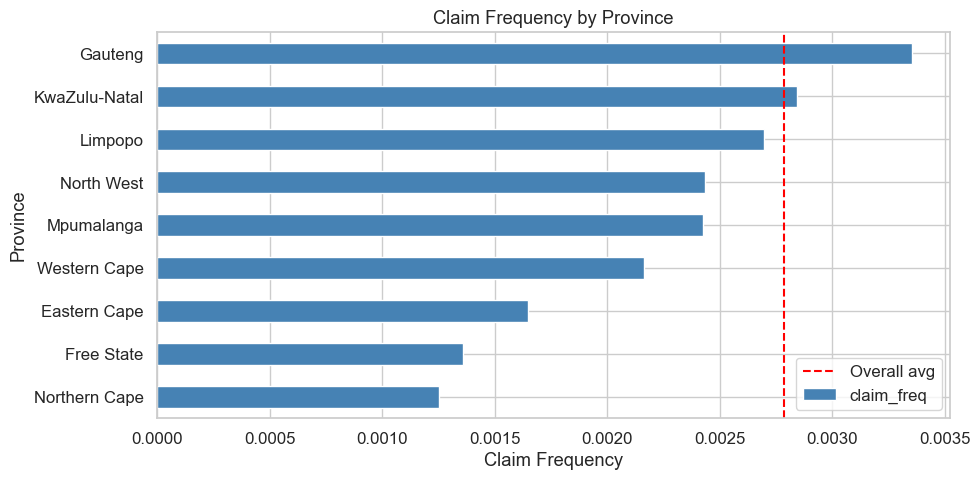

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
province_stats['claim_freq'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Claim Frequency')
ax.set_title('Claim Frequency by Province')
ax.axvline(df['HasClaim'].mean(), color='red', linestyle='--', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Overall chi-squared test (all provinces)

In [7]:
chi2_all, p_all = chi_squared_test_multi(df, 'Province', 'HasClaim')
print(f'Chi-squared statistic: {chi2_all:.4f}')
print(f'p-value:               {p_all:.2e}')
print(f'Decision (α=0.05):     {"Reject H₀" if p_all < 0.05 else "Fail to reject H₀"}')

Chi-squared statistic: 104.1909
p-value:               5.93e-19
Decision (α=0.05):     Reject H₀


### 2.3 Focused A/B test: Gauteng vs Western Cape

Provinces have 9 categories. We select the two **largest** provinces with meaningfully
different claim rates for a controlled pairwise comparison.

#### 2.3.1 Balance check on confounders

Before running the test, we verify that the two groups are statistically equivalent on
client, vehicle, and plan attributes — so any observed difference can be attributed to province.

In [8]:
prov_a = 'Gauteng'
prov_b = 'Western Cape'

grp_a_prov, grp_b_prov = select_two_groups(df, 'Province', prov_a, prov_b)
print(f'Group A (Control): {prov_a}  —  n = {len(grp_a_prov):,}')
print(f'Group B (Test):    {prov_b}  —  n = {len(grp_b_prov):,}')
print()

# Check balance on key confounders (client, vehicle, plan attributes)
balance_cols_prov = ['VehicleType', 'CoverType', 'CoverCategory', 'Product', 'Section', 'bodytype']
balance_prov = compare_group_balance(grp_a_prov, grp_b_prov, balance_cols_prov)
print('Balance check — are confounders statistically equivalent (p ≥ 0.05)?')
balance_prov

Group A (Control): Gauteng  —  n = 393,865
Group B (Test):    Western Cape  —  n = 170,796



Balance check — are confounders statistically equivalent (p ≥ 0.05)?


,column,test,statistic,p_value,equivalent
0,VehicleType,chi2,3319.6975,0.0000,False
1,CoverType,chi2,8979.1831,0.0000,False
2,CoverCategory,chi2,12674.2101,0.0000,False
3,Product,chi2,21073.2619,0.0000,False
4,Section,chi2,2859.9523,0.0000,False
5,bodytype,chi2,30244.2677,0.0000,False


#### 2.3.2 Run A/B test

In [9]:
result_h1 = run_frequency_test(
    df, 'Province', prov_a, prov_b,
    hypothesis_label='H1: Risk differences across provinces',
)

# Interpret
pct_diff = ((result_h1.group_a_metric - result_h1.group_b_metric) / result_h1.group_b_metric) * 100

if result_h1.reject:
    result_h1.interpretation = (
        f"We reject H₀ for provinces (p = {result_h1.p_value:.2e}). "
        f"{prov_a} exhibits a {abs(pct_diff):.0f}% {'higher' if pct_diff > 0 else 'lower'} "
        f"claim frequency than {prov_b} "
        f"({result_h1.group_a_metric:.4f} vs {result_h1.group_b_metric:.4f}), "
        f"suggesting a regional risk adjustment to premiums may be warranted."
    )
else:
    result_h1.interpretation = (
        f"We fail to reject H₀ (p = {result_h1.p_value:.4f}). "
        f"No statistically significant difference in claim frequency between "
        f"{prov_a} and {prov_b}."
    )

print(f'Claim frequency — {prov_a}: {result_h1.group_a_metric:.4f}  |  {prov_b}: {result_h1.group_b_metric:.4f}')
print(f'Difference: {pct_diff:+.1f}%')
print(f'Chi² = {result_h1.statistic:.4f},  p = {result_h1.p_value:.2e}')
print(f'Decision: {result_h1.decision}')
print()
print('Interpretation:', result_h1.interpretation)

all_results.append(result_h1)

Claim frequency — Gauteng: 0.0034  |  Western Cape: 0.0022
Difference: +54.9%
Chi² = 56.0874,  p = 6.93e-14
Decision: Reject H₀

Interpretation: We reject H₀ for provinces (p = 6.93e-14). Gauteng exhibits a 55% higher claim frequency than Western Cape (0.0034 vs 0.0022), suggesting a regional risk adjustment to premiums may be warranted.


---
## 3. Hypothesis 2 — Risk Differences Between Zip Codes

**H₀:** There are no risk differences between zip codes.  
**KPI:** Claim Frequency  
**Test:** Chi-squared test  

### 3.1 Select two large zip codes and check balance

In [10]:
# Examine claim frequency for the top zip codes
top_zips = df['PostalCode'].value_counts().head(10).index.tolist()
zip_stats = (
    df[df['PostalCode'].isin(top_zips)]
    .groupby('PostalCode')
    .agg(
        n_policies=('HasClaim', 'count'),
        n_claims=('HasClaim', 'sum'),
        claim_freq=('HasClaim', 'mean'),
        avg_premium=('TotalPremium', 'mean'),
    )
    .sort_values('claim_freq', ascending=False)
)
zip_stats

,n_policies,n_claims,claim_freq,avg_premium
PostalCode,,,,
8000,11794,51,0.0043,129.6268
470,10226,44,0.0043,58.7762
122,49171,210,0.0043,54.7068
2000,133498,486,0.0036,61.7727
2196,11048,32,0.0029,126.0240
7100,10161,28,0.0028,65.1215
299,25546,67,0.0026,55.2881
458,13775,32,0.0023,51.3794
7784,28585,50,0.0017,48.0237


In [11]:
# Select two zip codes with adequate sample sizes & different frequencies
# We pick the highest and lowest claim-frequency among the large zip codes
zip_a = int(zip_stats.index[0])   # highest claim frequency
zip_b = int(zip_stats.index[-1])  # lowest claim frequency

print(f'Group A (Control): PostalCode {zip_a}  —  claim freq = {zip_stats.loc[zip_a, "claim_freq"]:.4f}')
print(f'Group B (Test):    PostalCode {zip_b}  —  claim freq = {zip_stats.loc[zip_b, "claim_freq"]:.4f}')

Group A (Control): PostalCode 8000  —  claim freq = 0.0043
Group B (Test):    PostalCode 7405  —  claim freq = 0.0016


In [12]:
# Check balance on key confounders (client, vehicle, plan attributes)
grp_a_zip, grp_b_zip = select_two_groups(df, 'PostalCode', zip_a, zip_b)

balance_cols = ['VehicleType', 'CoverType', 'CoverCategory', 'Product', 'Section', 'bodytype']
balance_df = compare_group_balance(grp_a_zip, grp_b_zip, balance_cols)
print('Balance check — are confounders statistically equivalent (p ≥ 0.05)?')
balance_df

Balance check — are confounders statistically equivalent (p ≥ 0.05)?


,column,test,statistic,p_value,equivalent
0,VehicleType,chi2,75.2098,0.0000,False
1,CoverType,chi2,659.5620,0.0000,False
2,CoverCategory,chi2,739.8650,0.0000,False
3,Product,chi2,219.0934,0.0000,False
4,Section,chi2,466.7971,0.0000,False
5,bodytype,chi2,776.4154,0.0000,False


### 3.2 Run A/B test

In [13]:
result_h2 = run_frequency_test(
    df, 'PostalCode', zip_a, zip_b,
    hypothesis_label='H2: Risk differences between zip codes',
)

pct_diff_zip = ((result_h2.group_a_metric - result_h2.group_b_metric) / result_h2.group_b_metric) * 100 if result_h2.group_b_metric else 0

if result_h2.reject:
    result_h2.interpretation = (
        f"We reject H₀ for zip codes (p = {result_h2.p_value:.2e}). "
        f"Zip code {zip_a} shows a {abs(pct_diff_zip):.0f}% {'higher' if pct_diff_zip > 0 else 'lower'} "
        f"claim frequency than zip code {zip_b} "
        f"({result_h2.group_a_metric:.4f} vs {result_h2.group_b_metric:.4f}). "
        f"Zip-code-level risk factors should be incorporated into the pricing model."
    )
else:
    result_h2.interpretation = (
        f"We fail to reject H₀ (p = {result_h2.p_value:.4f}). "
        f"No statistically significant claim-frequency difference between "
        f"zip codes {zip_a} and {zip_b}."
    )

print(f'Claim frequency — Zip {zip_a}: {result_h2.group_a_metric:.4f}  |  Zip {zip_b}: {result_h2.group_b_metric:.4f}')
print(f'Chi² = {result_h2.statistic:.4f},  p = {result_h2.p_value:.2e}')
print(f'Decision: {result_h2.decision}')
print()
print('Interpretation:', result_h2.interpretation)

all_results.append(result_h2)

Claim frequency — Zip 8000: 0.0043  |  Zip 7405: 0.0016
Chi² = 19.7892,  p = 8.65e-06
Decision: Reject H₀

Interpretation: We reject H₀ for zip codes (p = 8.65e-06). Zip code 8000 shows a 176% higher claim frequency than zip code 7405 (0.0043 vs 0.0016). Zip-code-level risk factors should be incorporated into the pricing model.


---
## 4. Hypothesis 3 — Margin Differences Between Zip Codes

**H₀:** There is no significant margin (profit) difference between zip codes.  
**KPI:** Margin = TotalPremium − TotalClaims  
**Test:** z-test (large samples)

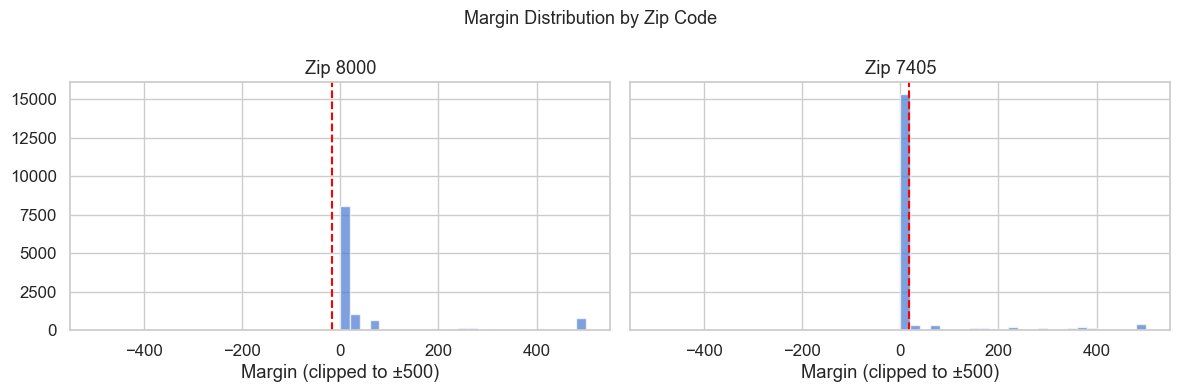

In [14]:
# Margin distribution for the two selected zip codes
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, grp) in zip(axes, [('Zip ' + str(zip_a), grp_a_zip), ('Zip ' + str(zip_b), grp_b_zip)]):
    grp_m = add_margin(grp)
    # Clip for visibility
    clipped = grp_m['Margin'].clip(-500, 500)
    ax.hist(clipped, bins=50, edgecolor='white', alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel('Margin (clipped to ±500)')
    ax.axvline(grp_m['Margin'].mean(), color='red', linestyle='--')
plt.suptitle('Margin Distribution by Zip Code', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
result_h3 = run_margin_test(
    df, 'PostalCode', zip_a, zip_b,
    hypothesis_label='H3: Margin differences between zip codes',
    use_ztest=True,
)

if result_h3.reject:
    result_h3.interpretation = (
        f"We reject H₀ for margin differences between zip codes (p = {result_h3.p_value:.2e}). "
        f"Zip code {zip_a} has an average margin of {result_h3.group_a_metric:,.2f} "
        f"compared to {result_h3.group_b_metric:,.2f} for zip code {zip_b}. "
        f"This indicates that profitability varies significantly by geography, "
        f"and premium adjustments or underwriting criteria should differ by zip code."
    )
else:
    result_h3.interpretation = (
        f"We fail to reject H₀ (p = {result_h3.p_value:.4f}). "
        f"No statistically significant margin difference between "
        f"zip codes {zip_a} and {zip_b}. Although claim frequencies differ, "
        f"current premium levels appear to partially compensate, "
        f"or the high variance in individual margins masks the signal."
    )

print(f'Avg margin — Zip {zip_a}: {result_h3.group_a_metric:,.2f}  |  Zip {zip_b}: {result_h3.group_b_metric:,.2f}')
print(f'z = {result_h3.statistic:.4f},  p = {result_h3.p_value:.2e}')
print(f'Decision: {result_h3.decision}')
print()
print('Interpretation:', result_h3.interpretation)

all_results.append(result_h3)

Avg margin — Zip 8000: -16.04  |  Zip 7405: 17.52
z = -0.8918,  p = 3.73e-01
Decision: Fail to reject H₀

Interpretation: We fail to reject H₀ (p = 0.3725). No statistically significant margin difference between zip codes 8000 and 7405. Although claim frequencies differ, current premium levels appear to partially compensate, or the high variance in individual margins masks the signal.


---
## 5. Hypothesis 4 — Risk Differences Between Women and Men

**H₀:** There is no significant risk difference between Women and Men.  
**KPI:** Claim Frequency  
**Test:** Chi-squared test  

> **Note:** ~95% of records have Gender = NaN. The test uses only the ~49,572 records where Gender is known.  
> Gender is already binary (Female / Male), so no group-selection or balance check is needed.

In [16]:
# Filter to records with known Gender
df_gender = df.dropna(subset=['Gender']).copy()
print(f'Records with known Gender: {len(df_gender):,}')
print()
print(df_gender.groupby('Gender').agg(
    n_policies=('HasClaim', 'count'),
    n_claims=('HasClaim', 'sum'),
    claim_freq=('HasClaim', 'mean'),
))

Records with known Gender: 49,572

        n_policies  n_claims  claim_freq
Gender                                  
Female        6755        14      0.0021
Male         42817        94      0.0022


In [17]:
result_h4 = run_frequency_test(
    df_gender, 'Gender', 'Female', 'Male',
    hypothesis_label='H4: Risk differences between Women and Men',
)

if result_h4.reject:
    pct_diff_g = ((result_h4.group_a_metric - result_h4.group_b_metric) / result_h4.group_b_metric) * 100
    result_h4.interpretation = (
        f"We reject H₀ for gender (p = {result_h4.p_value:.2e}). "
        f"Women show a {abs(pct_diff_g):.0f}% {'higher' if pct_diff_g > 0 else 'lower'} "
        f"claim frequency than Men "
        f"({result_h4.group_a_metric:.4f} vs {result_h4.group_b_metric:.4f}). "
        f"Gender-based risk segmentation should be considered where regulations allow."
    )
else:
    result_h4.interpretation = (
        f"We fail to reject H₀ (p = {result_h4.p_value:.4f}). "
        f"No statistically significant claim-frequency difference between "
        f"Women ({result_h4.group_a_metric:.4f}) and Men ({result_h4.group_b_metric:.4f}). "
        f"Gender does not appear to be a significant risk differentiator in this dataset. "
        f"Note: ~95% of records lack gender data, so this conclusion is limited to the available subset."
    )

print(f'Claim frequency — Female: {result_h4.group_a_metric:.4f}  |  Male: {result_h4.group_b_metric:.4f}')
print(f'Chi² = {result_h4.statistic:.4f},  p = {result_h4.p_value:.4f}')
print(f'Decision: {result_h4.decision}')
print()
print('Interpretation:', result_h4.interpretation)

all_results.append(result_h4)

Claim frequency — Female: 0.0021  |  Male: 0.0022
Chi² = 0.0037,  p = 0.9515
Decision: Fail to reject H₀

Interpretation: We fail to reject H₀ (p = 0.9515). No statistically significant claim-frequency difference between Women (0.0021) and Men (0.0022). Gender does not appear to be a significant risk differentiator in this dataset. Note: ~95% of records lack gender data, so this conclusion is limited to the available subset.


---
## 6. Summary Results Table

In [18]:
summary = results_table(all_results)
summary

,Hypothesis,KPI,Group A,Group B,Test,Statistic,p-value,α,Decision
0,H1: Risk differences across provinces,Claim Frequency,Gauteng,Western Cape,Chi-squared,56.0874,6.93e-14,0.0500,Reject H₀
1,H2: Risk differences between zip codes,Claim Frequency,8000,7405,Chi-squared,19.7892,8.65e-06,0.0500,Reject H₀
2,H3: Margin differences between zip codes,Margin,8000,7405,z-test,-0.8918,0.3725,0.0500,Fail to reject H₀
3,H4: Risk differences between Women and Men,Claim Frequency,Female,Male,Chi-squared,0.0037,0.9515,0.0500,Fail to reject H₀


In [19]:
# Visual summary — highlight rejected hypotheses
def highlight_decision(val):
    if val == 'Reject H₀':
        return 'background-color: #ffcccc; font-weight: bold'
    elif val == 'Fail to reject H₀':
        return 'background-color: #ccffcc'
    return ''

if hasattr(summary.style, 'map'):
    summary.style.map(highlight_decision, subset=['Decision'])
else:
    summary.style.applymap(highlight_decision, subset=['Decision'])


---
## 7. Business Interpretations & Recommendations

In [20]:
print('=' * 80)
print('BUSINESS INTERPRETATIONS & RECOMMENDATIONS')
print('=' * 80)

for i, r in enumerate(all_results, 1):
    print(f'\n--- Hypothesis {i}: {r.hypothesis} ---')
    print(f'KPI: {r.kpi}  |  Test: {r.test_name}  |  p-value: {r.p_value:.2e}')
    print(f'Decision: {r.decision}')
    print(f'\n  {r.interpretation}')
    print()

BUSINESS INTERPRETATIONS & RECOMMENDATIONS

--- Hypothesis 1: H1: Risk differences across provinces ---
KPI: Claim Frequency  |  Test: Chi-squared  |  p-value: 6.93e-14
Decision: Reject H₀

  We reject H₀ for provinces (p = 6.93e-14). Gauteng exhibits a 55% higher claim frequency than Western Cape (0.0034 vs 0.0022), suggesting a regional risk adjustment to premiums may be warranted.


--- Hypothesis 2: H2: Risk differences between zip codes ---
KPI: Claim Frequency  |  Test: Chi-squared  |  p-value: 8.65e-06
Decision: Reject H₀

  We reject H₀ for zip codes (p = 8.65e-06). Zip code 8000 shows a 176% higher claim frequency than zip code 7405 (0.0043 vs 0.0016). Zip-code-level risk factors should be incorporated into the pricing model.


--- Hypothesis 3: H3: Margin differences between zip codes ---
KPI: Margin  |  Test: z-test  |  p-value: 3.73e-01
Decision: Fail to reject H₀

  We fail to reject H₀ (p = 0.3725). No statistically significant margin difference between zip codes 8000 and

In [21]:
# Save results table to reports/
os.makedirs('../reports', exist_ok=True)
summary.to_csv('../reports/hypothesis_test_results.csv', index=False)

# Save interpretations
with open('../reports/hypothesis_test_interpretations.txt', 'w') as f:
    f.write('A/B HYPOTHESIS TESTING — RESULTS & INTERPRETATIONS\n')
    f.write('=' * 60 + '\n\n')
    for i, r in enumerate(all_results, 1):
        f.write(f'Hypothesis {i}: {r.hypothesis}\n')
        f.write(f'  KPI:       {r.kpi}\n')
        f.write(f'  Test:      {r.test_name}\n')
        f.write(f'  Statistic: {r.statistic:.4f}\n')
        f.write(f'  p-value:   {r.p_value:.2e}\n')
        f.write(f'  Decision:  {r.decision}\n')
        f.write(f'  Interpretation: {r.interpretation}\n')
        f.write('\n')

print('Results saved to reports/hypothesis_test_results.csv')
print('Interpretations saved to reports/hypothesis_test_interpretations.txt')

Results saved to reports/hypothesis_test_results.csv
Interpretations saved to reports/hypothesis_test_interpretations.txt
